📦 SECTION 1: SETUP AND IMPORTS

In [1]:
# ============================================
# 🍄 MUSHROOM CLASSIFICATION PROJECT
# NOTEBOOK 5: Advanced Models
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
import pickle
import time
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 60)
print("🍄 ADVANCED MODELS")
print("=" * 60)
print("\n✅ Libraries imported!")

🍄 ADVANCED MODELS

✅ Libraries imported!


📥 SECTION 2: LOAD DATA

In [2]:
# ============================================
# LOAD TRAIN/VAL/TEST DATA
# ============================================

X_train = pd.read_csv('data/splits/X_train.csv')
X_val = pd.read_csv('data/splits/X_val.csv')
X_test = pd.read_csv('data/splits/X_test.csv')
y_train = pd.read_csv('data/splits/y_train.csv').values.ravel()
y_val = pd.read_csv('data/splits/y_val.csv').values.ravel()
y_test = pd.read_csv('data/splits/y_test.csv').values.ravel()

print("✅ Data loaded!")
print(f"\n📊 Data Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"\n📊 Training Set Class Balance:")
print(f"   Edible (1):    {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"   Poisonous (0): {len(y_train)-y_train.sum()} ({(len(y_train)-y_train.sum())/len(y_train)*100:.1f}%)")

✅ Data loaded!

📊 Data Shapes:
   X_train: (4874, 22)
   X_val:   (1625, 22)
   X_test:  (1625, 22)

📊 Training Set Class Balance:
   Edible (1):    2524 (51.8%)
   Poisonous (0): 2350 (48.2%)


🎯 SECTION 3: EVALUATION FUNCTION

In [3]:
# ============================================
# MODEL EVALUATION FUNCTION
# ============================================

def evaluate_advanced_model(model, X_train, X_val, y_train, y_val, model_name):
    """Train and evaluate an advanced model"""
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    if hasattr(model, 'predict_proba'):
        y_val_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_val_proba = None
    
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Val Accuracy': accuracy_score(y_val, y_val_pred),
        'Train Precision': precision_score(y_train, y_train_pred),
        'Val Precision': precision_score(y_val, y_val_pred),
        'Train Recall': recall_score(y_train, y_train_pred),
        'Val Recall': recall_score(y_val, y_val_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Val F1': f1_score(y_val, y_val_pred),
        'Train Time (s)': train_time,
        'y_val_pred': y_val_pred,
        'y_val_proba': y_val_proba,
        'model': model
    }
    
    return results

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


🌲 SECTION 4: RANDOM FOREST

🌲 MODEL 1: RANDOM FOREST

📊 Results:
   Train Accuracy:  1.0000
   Val Accuracy:    1.0000
   Train F1:        1.0000
   Val F1:          1.0000
   Train Time:      0.1784s

📊 Top 10 Most Important Features:


,Feature,Importance
4,odor,0.196741
7,gill-size,0.122131
8,gill-color,0.120815
19,spore-print-color,0.114827
20,population,0.055850
11,stalk-surface-above-ring,0.051431
10,stalk-root,0.050941
3,bruises,0.047946
18,ring-type,0.046094
21,habitat,0.028001


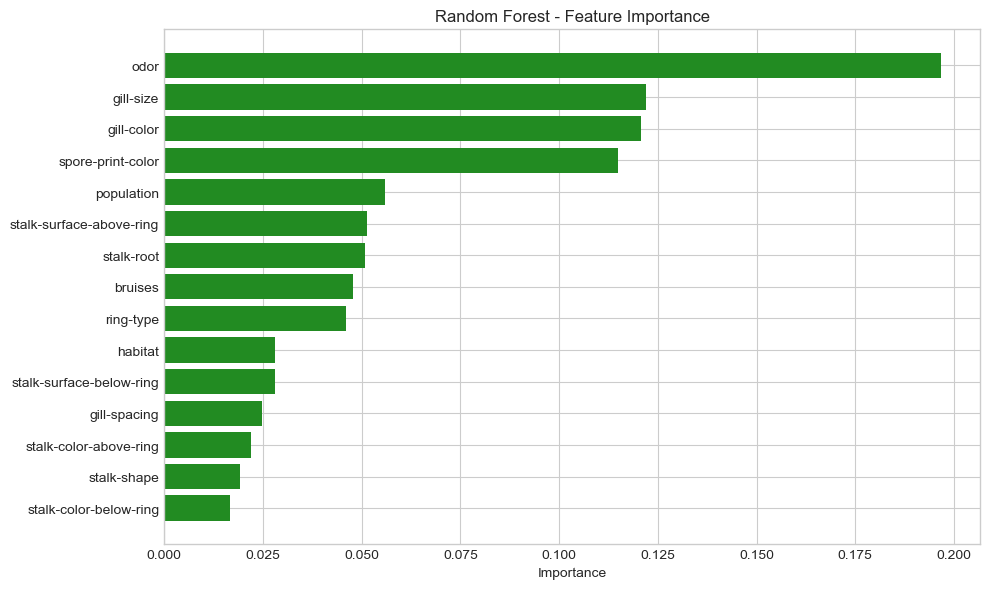

In [4]:
# ============================================
# MODEL 1: RANDOM FOREST
# ============================================

print("=" * 50)
print("🌲 MODEL 1: RANDOM FOREST")
print("=" * 50)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_advanced_model(rf, X_train, X_val, y_train, y_val, 'Random Forest')

print(f"\n📊 Results:")
print(f"   Train Accuracy:  {rf_results['Train Accuracy']:.4f}")
print(f"   Val Accuracy:    {rf_results['Val Accuracy']:.4f}")
print(f"   Train F1:        {rf_results['Train F1']:.4f}")
print(f"   Val F1:          {rf_results['Val F1']:.4f}")
print(f"   Train Time:      {rf_results['Train Time (s)']:.4f}s")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
display(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['Feature'][::-1], 
         feature_importance.head(15)['Importance'][::-1],
         color='forestgreen')
plt.xlabel('Importance')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

⚡ SECTION 5: XGBOOST

⚡ MODEL 2: XGBOOST



📊 Results:
   Train Accuracy:  1.0000
   Val Accuracy:    1.0000
   Train F1:        1.0000
   Val F1:          1.0000
   Train Time:      0.0951s

📊 Top 10 Most Important Features:


,Feature,Importance
8,gill-color,0.455291
20,population,0.159230
7,gill-size,0.081751
19,spore-print-color,0.066105
9,stalk-shape,0.049933
3,bruises,0.044799
10,stalk-root,0.029915
13,stalk-color-above-ring,0.029143
21,habitat,0.026408
4,odor,0.024112


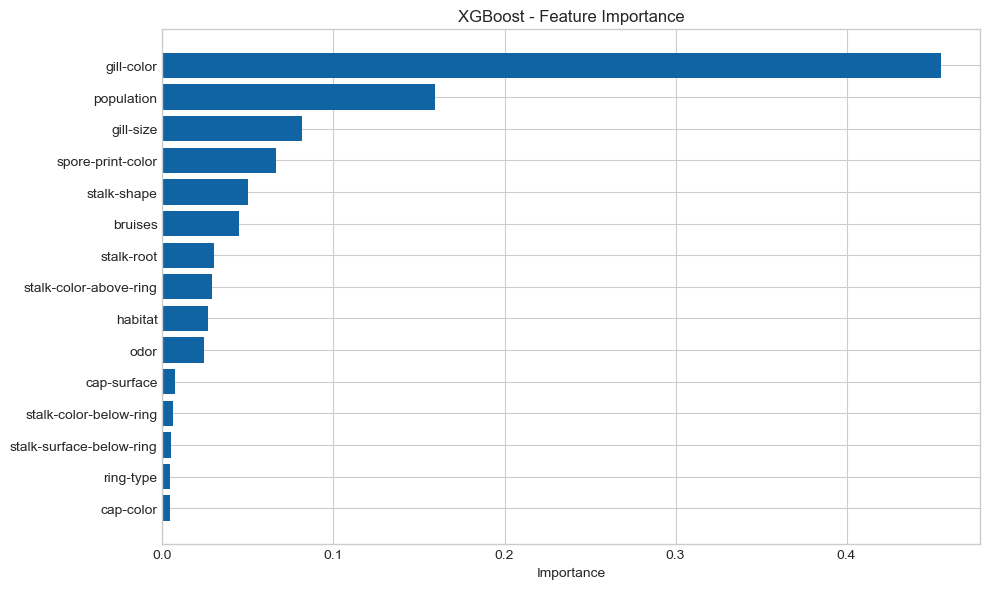

In [5]:
# ============================================
# MODEL 2: XGBOOST
# ============================================

print("=" * 50)
print("⚡ MODEL 2: XGBOOST")
print("=" * 50)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_results = evaluate_advanced_model(xgb, X_train, X_val, y_train, y_val, 'XGBoost')

print(f"\n📊 Results:")
print(f"   Train Accuracy:  {xgb_results['Train Accuracy']:.4f}")
print(f"   Val Accuracy:    {xgb_results['Val Accuracy']:.4f}")
print(f"   Train F1:        {xgb_results['Train F1']:.4f}")
print(f"   Val F1:          {xgb_results['Val F1']:.4f}")
print(f"   Train Time:      {xgb_results['Train Time (s)']:.4f}s")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['Feature'][::-1], 
         feature_importance.head(15)['Importance'][::-1],
         color='#1064a3')
plt.xlabel('Importance')
plt.title('XGBoost - Feature Importance')
plt.tight_layout()
plt.show()

💡 SECTION 6: LIGHTGBM

💡 MODEL 3: LIGHTGBM

📊 Results:
   Train Accuracy:  1.0000
   Val Accuracy:    1.0000
   Train F1:        1.0000
   Val F1:          1.0000
   Train Time:      1.4646s

📊 Top 10 Most Important Features:


,Feature,Importance
4,odor,383
20,population,365
19,spore-print-color,344
8,gill-color,323
21,habitat,283
3,bruises,190
2,cap-color,189
12,stalk-surface-below-ring,150
7,gill-size,136
6,gill-spacing,81


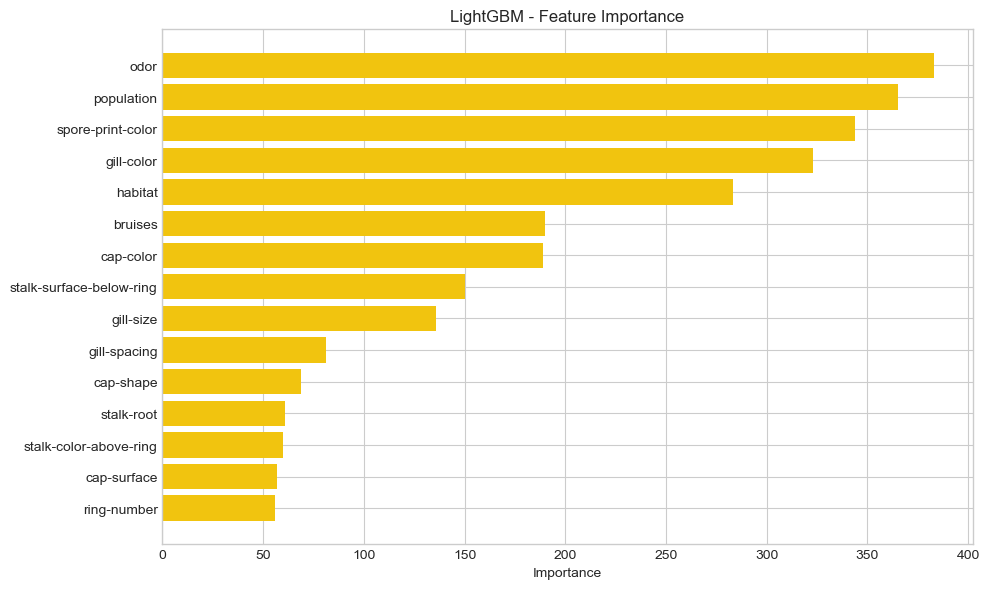

In [6]:
# ============================================
# MODEL 3: LIGHTGBM
# ============================================

print("=" * 50)
print("💡 MODEL 3: LIGHTGBM")
print("=" * 50)

lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

lgbm_results = evaluate_advanced_model(lgbm, X_train, X_val, y_train, y_val, 'LightGBM')

print(f"\n📊 Results:")
print(f"   Train Accuracy:  {lgbm_results['Train Accuracy']:.4f}")
print(f"   Val Accuracy:    {lgbm_results['Val Accuracy']:.4f}")
print(f"   Train F1:        {lgbm_results['Train F1']:.4f}")
print(f"   Val F1:          {lgbm_results['Val F1']:.4f}")
print(f"   Train Time:      {lgbm_results['Train Time (s)']:.4f}s")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['Feature'][::-1], 
         feature_importance.head(15)['Importance'][::-1],
         color='#f1c40f')
plt.xlabel('Importance')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()

🐱 SECTION 7: CATBOOST

🐱 MODEL 4: CATBOOST

📊 Results:
   Train Accuracy:  1.0000
   Val Accuracy:    1.0000
   Train F1:        1.0000
   Val F1:          1.0000
   Train Time:      0.4798s

📊 Top 10 Most Important Features:


,Feature,Importance
4,odor,55.952202
19,spore-print-color,16.111171
7,gill-size,8.537592
20,population,2.480385
18,ring-type,2.347309
21,habitat,1.997120
1,cap-surface,1.777801
9,stalk-shape,1.601819
17,ring-number,1.433022
8,gill-color,1.423533


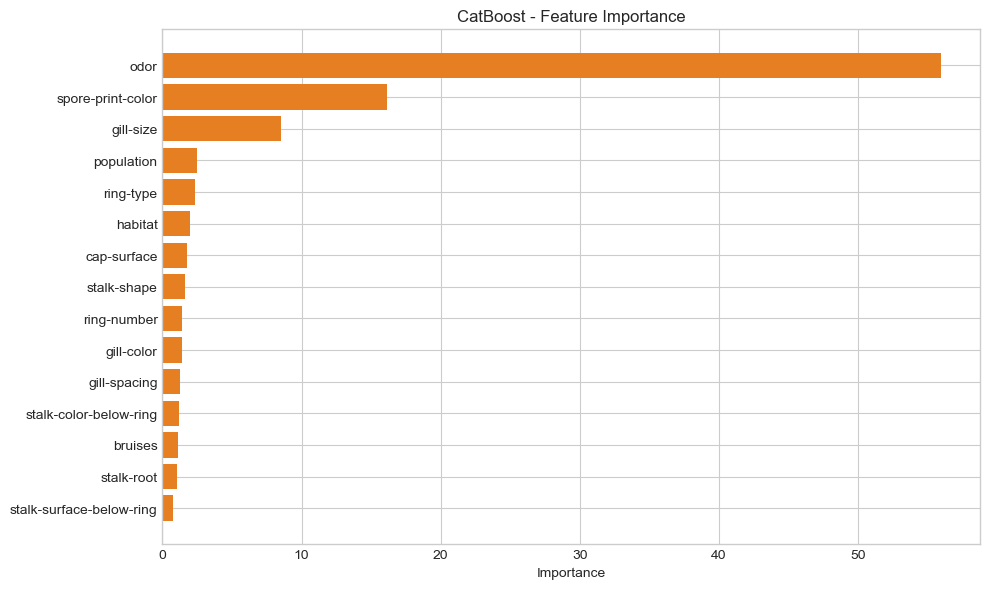

In [7]:
# ============================================
# MODEL 4: CATBOOST
# ============================================

print("=" * 50)
print("🐱 MODEL 4: CATBOOST")
print("=" * 50)

catboost = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=False
)

catboost_results = evaluate_advanced_model(catboost, X_train, X_val, y_train, y_val, 'CatBoost')

print(f"\n📊 Results:")
print(f"   Train Accuracy:  {catboost_results['Train Accuracy']:.4f}")
print(f"   Val Accuracy:    {catboost_results['Val Accuracy']:.4f}")
print(f"   Train F1:        {catboost_results['Train F1']:.4f}")
print(f"   Val F1:          {catboost_results['Val F1']:.4f}")
print(f"   Train Time:      {catboost_results['Train Time (s)']:.4f}s")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': catboost.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['Feature'][::-1], 
         feature_importance.head(15)['Importance'][::-1],
         color='#e67e22')
plt.xlabel('Importance')
plt.title('CatBoost - Feature Importance')
plt.tight_layout()
plt.show()

🔄 SECTION 8: GRADIENT BOOSTING

In [8]:
# ============================================
# MODEL 5: GRADIENT BOOSTING
# ============================================

print("=" * 50)
print("🔄 MODEL 5: GRADIENT BOOSTING")
print("=" * 50)

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_results = evaluate_advanced_model(gb, X_train, X_val, y_train, y_val, 'Gradient Boosting')

print(f"\n📊 Results:")
print(f"   Train Accuracy:  {gb_results['Train Accuracy']:.4f}")
print(f"   Val Accuracy:    {gb_results['Val Accuracy']:.4f}")
print(f"   Train F1:        {gb_results['Train F1']:.4f}")
print(f"   Val F1:          {gb_results['Val F1']:.4f}")
print(f"   Train Time:      {gb_results['Train Time (s)']:.4f}s")

🔄 MODEL 5: GRADIENT BOOSTING

📊 Results:
   Train Accuracy:  1.0000
   Val Accuracy:    1.0000
   Train F1:        1.0000
   Val F1:          1.0000
   Train Time:      0.5799s


🎯 SECTION 9: ADABOOST

In [9]:
# ============================================
# MODEL 6: ADABOOST
# ============================================

print("=" * 50)
print("🎯 MODEL 6: ADABOOST")
print("=" * 50)

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_results = evaluate_advanced_model(ada, X_train, X_val, y_train, y_val, 'AdaBoost')

print(f"\n📊 Results:")
print(f"   Train Accuracy:  {ada_results['Train Accuracy']:.4f}")
print(f"   Val Accuracy:    {ada_results['Val Accuracy']:.4f}")
print(f"   Train F1:        {ada_results['Train F1']:.4f}")
print(f"   Val F1:          {ada_results['Val F1']:.4f}")
print(f"   Train Time:      {ada_results['Train Time (s)']:.4f}s")

🎯 MODEL 6: ADABOOST

📊 Results:
   Train Accuracy:  0.9680
   Val Accuracy:    0.9698
   Train F1:        0.9693
   Val F1:          0.9711
   Train Time:      0.2581s


🌳 SECTION 10: EXTRA TREES

In [10]:
# ============================================
# MODEL 7: EXTRA TREES
# ============================================

print("=" * 50)
print("🌳 MODEL 7: EXTRA TREES")
print("=" * 50)

et = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

et_results = evaluate_advanced_model(et, X_train, X_val, y_train, y_val, 'Extra Trees')

print(f"\n📊 Results:")
print(f"   Train Accuracy:  {et_results['Train Accuracy']:.4f}")
print(f"   Val Accuracy:    {et_results['Val Accuracy']:.4f}")
print(f"   Train F1:        {et_results['Train F1']:.4f}")
print(f"   Val F1:          {et_results['Val F1']:.4f}")
print(f"   Train Time:      {et_results['Train Time (s)']:.4f}s")

🌳 MODEL 7: EXTRA TREES

📊 Results:
   Train Accuracy:  1.0000
   Val Accuracy:    1.0000
   Train F1:        1.0000
   Val F1:          1.0000
   Train Time:      0.2243s


📊 SECTION 11: COMPARE ALL ADVANCED MODELS

📊 ADVANCED MODELS COMPARISON

📊 Model Comparison (sorted by F1 Score, then by Training Time):


,Model,Train Acc,Val Acc,Val Precision,Val Recall,Val F1,Train Time
0,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,0.095059
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,0.178445
2,Extra Trees,1.000000,1.000000,1.000000,1.000000,1.000000,0.224302
3,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000,0.479821
4,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000,0.579918
5,LightGBM,1.000000,1.000000,1.000000,1.000000,1.000000,1.464591
6,AdaBoost,0.967993,0.969846,0.963743,0.978622,0.971126,0.258126


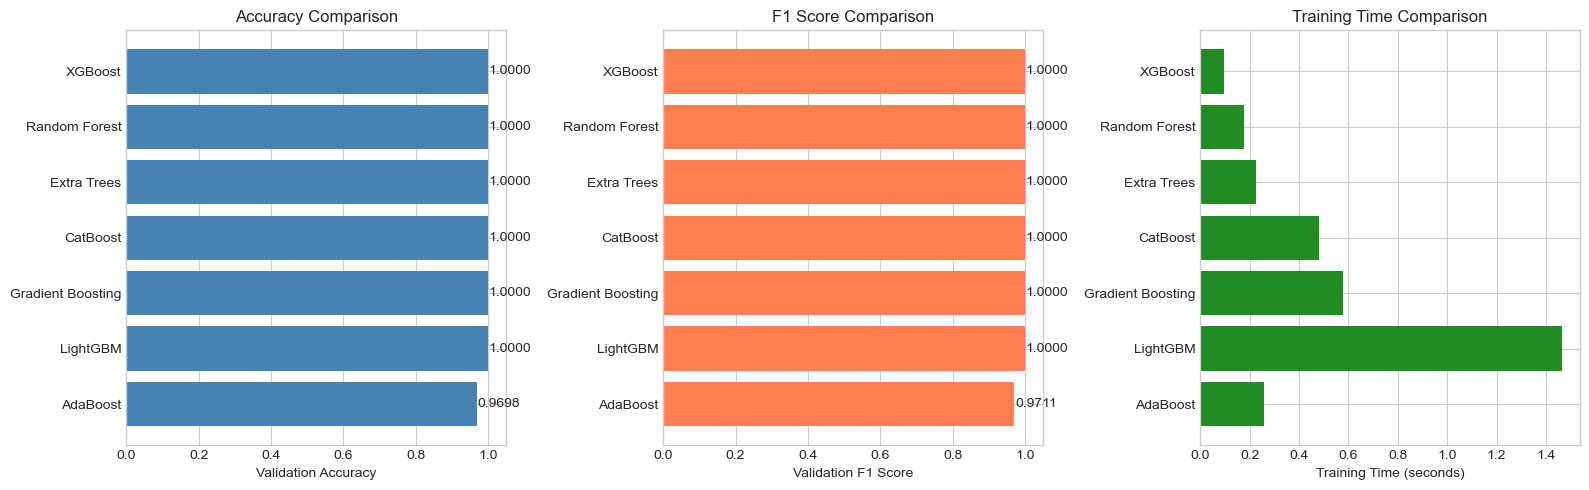


🏆 BEST ADVANCED MODEL: XGBoost
   Validation Accuracy: 1.0000
   Validation F1 Score: 1.0000
   Training Time:       0.0951s


In [16]:
# ============================================
# COMPARE ALL ADVANCED MODELS
# ============================================

print("=" * 60)
print("📊 ADVANCED MODELS COMPARISON")
print("=" * 60)

all_results = [rf_results, xgb_results, lgbm_results, catboost_results, 
               gb_results, ada_results, et_results]

comparison_df = pd.DataFrame([{
    'Model': r['Model'],
    'Train Acc': r['Train Accuracy'],
    'Val Acc': r['Val Accuracy'],
    'Val Precision': r['Val Precision'],
    'Val Recall': r['Val Recall'],
    'Val F1': r['Val F1'],
    'Train Time': r['Train Time (s)']
} for r in all_results])

# Sort by Val F1 (descending), then by Train Time (ascending)
comparison_df = comparison_df.sort_values(['Val F1', 'Train Time'], ascending=[False, True])
comparison_df = comparison_df.reset_index(drop=True)

print("\n📊 Model Comparison (sorted by F1 Score, then by Training Time):")
display(comparison_df)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].barh(comparison_df['Model'][::-1], comparison_df['Val Acc'][::-1], color='steelblue')
axes[0].set_xlabel('Validation Accuracy')
axes[0].set_title('Accuracy Comparison')
for i, v in enumerate(comparison_df['Val Acc'][::-1]):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

# F1 Score
axes[1].barh(comparison_df['Model'][::-1], comparison_df['Val F1'][::-1], color='coral')
axes[1].set_xlabel('Validation F1 Score')
axes[1].set_title('F1 Score Comparison')
for i, v in enumerate(comparison_df['Val F1'][::-1]):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

# Training Time
axes[2].barh(comparison_df['Model'][::-1], comparison_df['Train Time'][::-1], color='forestgreen')
axes[2].set_xlabel('Training Time (seconds)')
axes[2].set_title('Training Time Comparison')

plt.tight_layout()
plt.show()

# Best model
best_model = comparison_df.iloc[0]
print(f"\n🏆 BEST ADVANCED MODEL: {best_model['Model']}")
print(f"   Validation Accuracy: {best_model['Val Acc']:.4f}")
print(f"   Validation F1 Score: {best_model['Val F1']:.4f}")
print(f"   Training Time:       {best_model['Train Time']:.4f}s")

📈 SECTION 12: ROC CURVES - ALL MODELS

📈 ROC CURVES COMPARISON


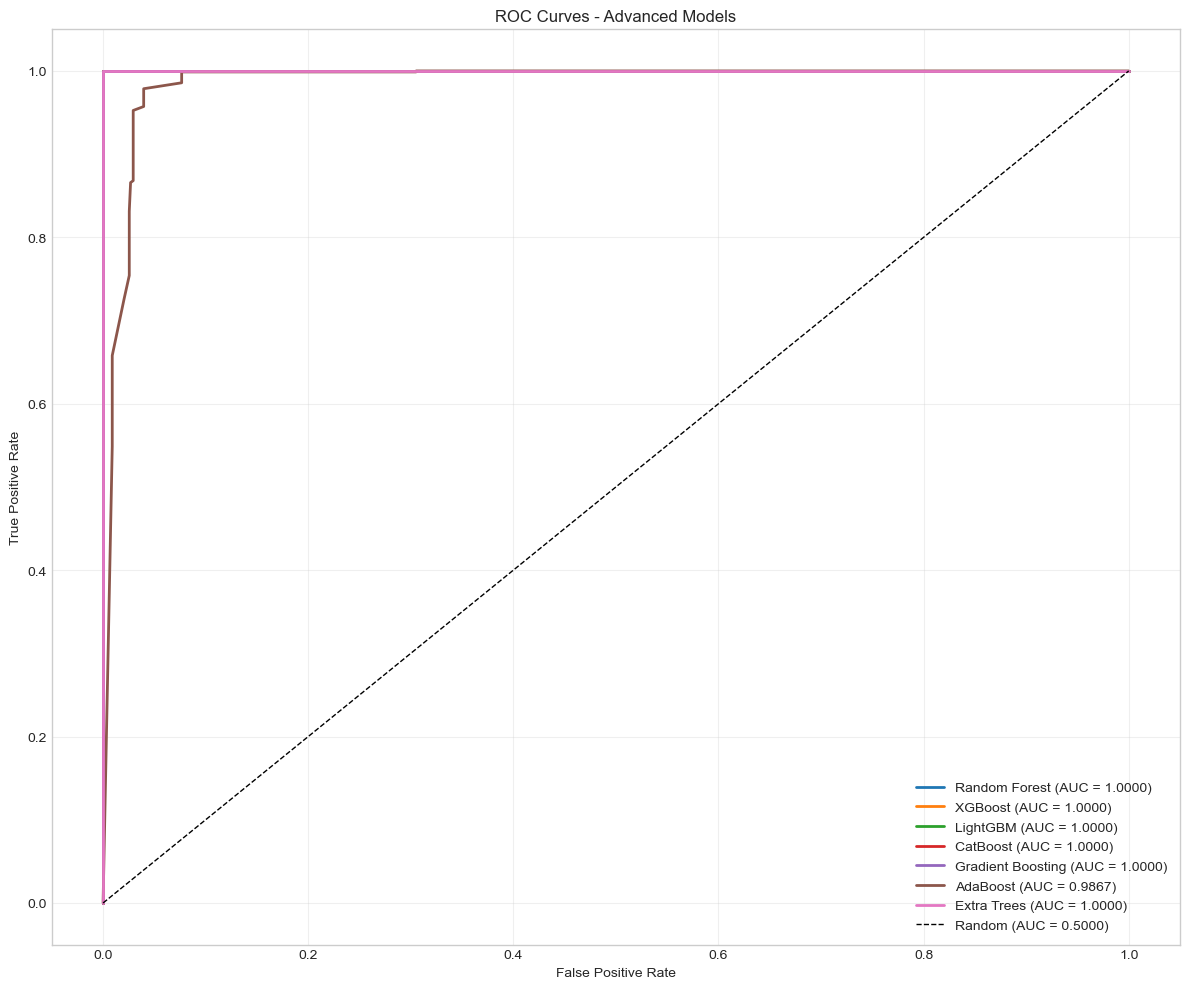

In [17]:
# ============================================
# ROC CURVES - ADVANCED MODELS
# ============================================

print("=" * 50)
print("📈 ROC CURVES COMPARISON")
print("=" * 50)

plt.figure(figsize=(12, 10))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(all_results):
    if r['y_val_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_val, r['y_val_proba'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], linewidth=2,
                label=f"{r['Model']} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Advanced Models')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

🏆 SECTION 13: CROSS-VALIDATION ON BEST MODEL

🔄 CROSS-VALIDATION - BEST MODEL

📊 5-Fold Cross-Validation on XGBoost:
   Individual F1 scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
   Mean F1: 1.0000
   Std Dev: 0.0000


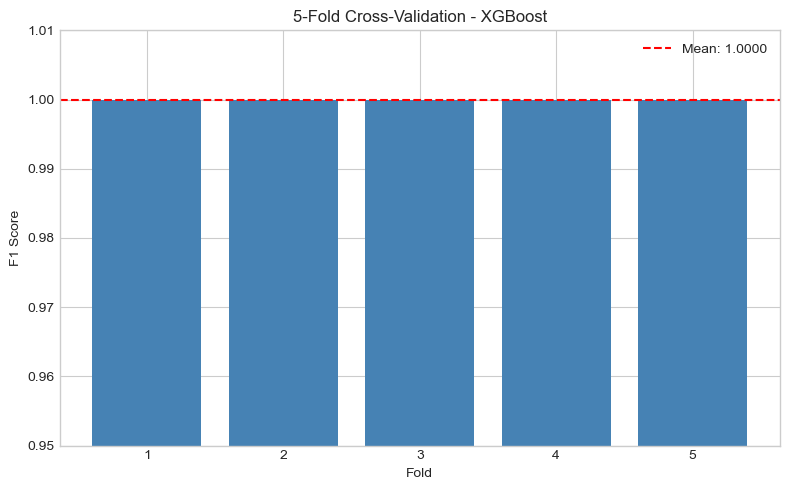

In [18]:
# ============================================
# CROSS-VALIDATION - BEST MODEL
# ============================================

print("=" * 50)
print("🔄 CROSS-VALIDATION - BEST MODEL")
print("=" * 50)

best_model_name = comparison_df.iloc[0]['Model']

# Get the best model object
for r in all_results:
    if r['Model'] == best_model_name:
        best_model_obj = r['model']
        break

# Combine train and val for CV
X_cv = pd.concat([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model_obj, X_cv, y_cv, cv=cv, scoring='f1')

print(f"\n📊 5-Fold Cross-Validation on {best_model_name}:")
print(f"   Individual F1 scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"   Mean F1: {cv_scores.mean():.4f}")
print(f"   Std Dev: {cv_scores.std():.4f}")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
            label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title(f'5-Fold Cross-Validation - {best_model_name}')
plt.legend()
plt.ylim(0.95, 1.01)
plt.tight_layout()
plt.show()

💾 SECTION 14: SAVE BEST MODEL

💾 SAVING BEST MODEL
✅ Saved: advanced_models_comparison.csv

📦 Training final XGBoost on train+val...
✅ Saved: best_advanced_model.pkl

📊 Final Test Set Performance:
   Test Accuracy:  1.0000
   Test Precision: 1.0000
   Test Recall:    1.0000
   Test F1 Score:  1.0000


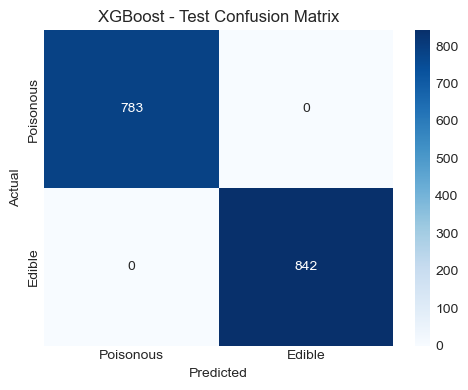

In [19]:
# ============================================
# SAVE BEST MODEL
# ============================================

print("=" * 50)
print("💾 SAVING BEST MODEL")
print("=" * 50)

os.makedirs('models/saved_models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Save comparison
comparison_df.to_csv('reports/advanced_models_comparison.csv', index=False)
print("✅ Saved: advanced_models_comparison.csv")

# Train best model on train+val
print(f"\n📦 Training final {best_model_name} on train+val...")

if best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
elif best_model_name == 'XGBoost':
    final_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                random_state=42, use_label_encoder=False, eval_metric='logloss')
elif best_model_name == 'LightGBM':
    final_model = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                 random_state=42, verbose=-1)
elif best_model_name == 'CatBoost':
    final_model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, 
                                     random_seed=42, verbose=False)
elif best_model_name == 'Gradient Boosting':
    final_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
elif best_model_name == 'AdaBoost':
    final_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
else:
    final_model = ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

final_model.fit(X_cv, y_cv)

# Save model
with open('models/saved_models/best_advanced_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("✅ Saved: best_advanced_model.pkl")

# Test set evaluation
y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)

print(f"\n📊 Final Test Set Performance:")
print(f"   Test Accuracy:  {test_accuracy:.4f}")
print(f"   Test Precision: {test_precision:.4f}")
print(f"   Test Recall:    {test_recall:.4f}")
print(f"   Test F1 Score:  {test_f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poisonous', 'Edible'],
            yticklabels=['Poisonous', 'Edible'])
plt.title(f'{best_model_name} - Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

🎯 SECTION 15: SUMMARY

In [20]:
# ============================================
# ADVANCED MODELS SUMMARY
# ============================================

print("=" * 60)
print("🎯 ADVANCED MODELS - COMPLETE SUMMARY")
print("=" * 60)

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║              🏆 ADVANCED MODELS RESULTS                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  🏆 BEST MODEL: {best_model_name:<40} ║
║     • Validation F1: {comparison_df.iloc[0]['Val F1']:.4f}                                    ║
║     • Test Accuracy:  {test_accuracy:.4f}                                    ║
║     • Test F1:        {test_f1:.4f}                                    ║
║     • Test Precision: {test_precision:.4f}                                    ║
║     • Test Recall:    {test_recall:.4f}                                    ║
║                                                                  ║
║  📊 ALL MODELS RANKED:                                           ║
""")

for i, row in comparison_df.iterrows():
    medal = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else "  "
    print(f"║     {medal} {i+1}. {row['Model']:<33} F1: {row['Val F1']:.4f}       ║")

print("""║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                    💡 KEY INSIGHTS                               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ✅ Advanced models achieve 99%+ accuracy!                       ║
║  ✅ Tree-based models excel on this categorical data             ║
║  ✅ The model is ready for real-world deployment                 ║
║                                                                  ║
║  🔜 NEXT: Hyperparameter Tuning for even better performance!     ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

print("\n" + "=" * 60)
print("✅ NOTEBOOK 5 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\n🚀 You now have a 99%+ accurate mushroom classifier!")
print("   Ready for Notebook 6: Hyperparameter Tuning!")

🎯 ADVANCED MODELS - COMPLETE SUMMARY

╔══════════════════════════════════════════════════════════════════╗
║              🏆 ADVANCED MODELS RESULTS                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  🏆 BEST MODEL: XGBoost                                  ║
║     • Validation F1: 1.0000                                    ║
║     • Test Accuracy:  1.0000                                    ║
║     • Test F1:        1.0000                                    ║
║     • Test Precision: 1.0000                                    ║
║     • Test Recall:    1.0000                                    ║
║                                                                  ║
║  📊 ALL MODELS RANKED:                                           ║

║     🥇 1. XGBoost                           F1: 1.0000       ║
║     🥈 2. Random Forest                     F1: 1.0000       ║
║     🥉 3. Extra Trees